In [2]:
from diffusers import UNet2DModel, DDPMScheduler, VQModel
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from utils import im2tensor, viewimage

seed = 7

In [4]:
# run only once
download = False
if download:
    !wget -nc -O ffhq256-1k-validation.zip 'https://www.dropbox.com/scl/fi/pppstbdsf0em6o0qscruc/ffhq256-1k-validation.zip?rlkey=xl7nwv2nxb6yvsirr3wad77hm'
    !unzip -nq ffhq256-1k-validation.zip
    vqvae = VQModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="vqvae")
    unet = UNet2DModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="unet")
    scheduler = DDPMScheduler.from_pretrained("CompVis/ldm-celebahq-256", subfolder="scheduler")
    vqvae.save_pretrained("./models/vqvae")
    unet.save_pretrained("./models/unet")
    scheduler.save_pretrained("./models/scheduler")
    
else:
    vqvae = VQModel.from_pretrained("./models/vqvae")
    unet = UNet2DModel.from_pretrained("./models/unet")
    scheduler = DDPMScheduler.from_pretrained("./models/scheduler")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
The config attributes {'timestep_values': None, 'timesteps': 1000} were passed to DDPMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

unet.to(device)
vqvae.to(device)

print(device)

cuda


/tmp/ipykernel_2698087/2673432712.py:7: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DModel's config object instead, e.g. 'unet.config.in_channels'.
  imgshape_latent = (1, unet.in_channels, unet.sample_size, unet.sample_size)


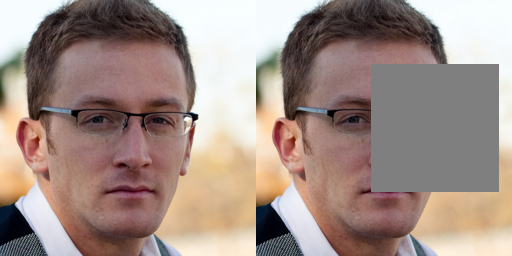

In [7]:
MODE = "inpainting"

idx = 462
x0 = im2tensor(plt.imread('ffhq256-1k-validation/'+str(idx).zfill(5)+'.png'), device=device)

imgshape = x0.shape
imgshape_latent = (1, unet.in_channels, unet.sample_size, unet.sample_size)

sigma_noise = 0.01

if MODE == "inpainting":
    h = imgshape[2]
    w = imgshape[3]
    hcrop, wcrop = h//2, w//2
    corner_top, corner_left = h//4, int(0.45*w)
    mask = torch.ones(imgshape, device=device)
    mask[:,:,corner_top:corner_top+hcrop,corner_left:corner_left+wcrop] = 0

    def linear_operator(x):
        x = x*mask
        return(x)

    x_true = x0.clone()

    y = linear_operator(x_true.clone()) + sigma_noise * mask * torch.randn_like(x_true)
    vis_y = y    
    
viewimage(torch.cat((x_true, vis_y), dim=3), titre='Ground truth and measurements', displayfilename=False)

In [13]:
scheduler.set_timesteps(num_inference_steps=100)
alphas = scheduler.alphas.to(device)
betas = scheduler.betas.to(device)
alphas_bar = scheduler.alphas_cumprod.to(device)
betas_bar = 1.0 - alphas_bar

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:21<00:00,  1.42s/it]


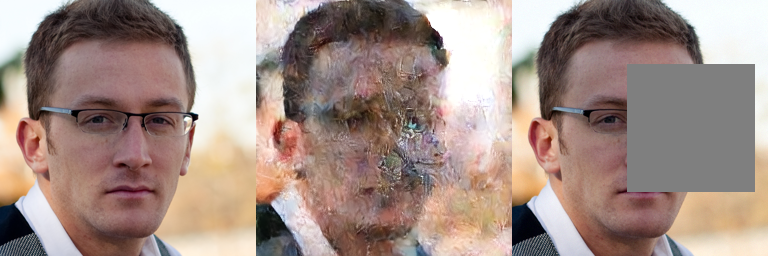

In [14]:
generator = torch.manual_seed(seed)
noise = torch.randn(
    imgshape_latent,
    generator=generator,
).to(device)

x = noise.clone()

unet.requires_grad_(False)
vqvae.requires_grad_(False)

for i, t in enumerate(tqdm(scheduler.timesteps)):
    t_tensor = torch.tensor([t], device=device)
    
    x = x.detach().requires_grad_(True)

    with torch.amp.autocast("cuda"):

        eps = unet(x, t_tensor)["sample"].detach()
        xhat_lat = 1/torch.sqrt(alphas_bar[t]) * (x - torch.sqrt(betas_bar[t]) * eps)
        xhat = vqvae.decode(xhat_lat)[0]
    
    resid = linear_operator(xhat) - y
    loss = (resid ** 2).sum()
    grad = torch.autograd.grad(loss, x)[0]
    zeta = 0.1/np.sqrt(loss.item())

    mu = (x - (betas[t_tensor] / torch.sqrt(betas_bar[t_tensor])) * eps) / torch.sqrt(alphas[t_tensor])

    if t > 0:
        z = torch.randn_like(x)
        x = mu + torch.sqrt(betas[t_tensor]) * z - zeta * grad
    else:
        x = mu - zeta * grad

final_img = vqvae.decode(x)[0]
viewimage(torch.cat((x_true, final_img, vis_y), dim=3), titre="Final_Results")